In [ ]:
import requests

cities = {
    "Москва": (55.75, 37.62),
    "Санкт-Петербург": (59.93, 30.32),
    "Новосибирск": (54.99, 82.90),
    "Екатеринбург": (56.83, 60.60),
    "Казань": (55.78, 49.12),
    "Челябинск": (55.15, 61.43),
    "Омск": (54.99, 73.37),
    "Самара": (53.20, 50.15),
    "Ростов-на-Дону": (47.23, 39.72),
    "Уфа": (54.73, 55.94),
    "Красноярск": (56.01, 92.87),
    "Пермь": (58.01, 56.23),
    "Воронеж": (51.67, 39.18),
    "Волгоград": (48.71, 44.51),
    "Краснодар": (45.04, 38.98),
    "Иркутск": (52.29, 104.28),
    "Хабаровск": (48.48, 135.08),
    "Владивосток": (43.11, 131.88),
    "Тюмень": (57.15, 68.99),
    "Барнаул": (53.35, 83.75),
}

weather_descriptions = {
    0: "ясно", 1: "преимущественно ясно", 2: "переменная облачность",
    3: "пасмурно", 45: "туман", 48: "изморозь", 51: "лёгкая морось",
    53: "умеренная морось", 61: "небольшой дождь", 63: "умеренный дождь",
    65: "сильный дождь", 71: "небольшой снег", 73: "умеренный снег",
    75: "сильный снег", 80: "ливень", 95: "гроза",
}

def fetch_weather_texts(cities):
    texts = []
    for city, (lat, lon) in cities.items():
        url = "https://api.open-meteo.com/v1/forecast"
        params = {
            "latitude": lat, "longitude": lon,
            "hourly": "temperature_2m,windspeed_10m,weathercode",
            "forecast_days": 16,
            "past_days": 30
        }
        r = requests.get(url, params=params)
        data = r.json()
        hourly = data["hourly"]

        for i in range(0, len(hourly["time"]), 3):
            code = hourly["weathercode"][i]
            desc = weather_descriptions.get(code, "облачно")
            temp = hourly["temperature_2m"][i]
            wind = hourly["windspeed_10m"][i]
            text = f"В городе {city}: {desc}, температура {temp:.0f}°C, ветер {wind:.0f} км/ч."
            texts.append(text)

    return texts



In [ ]:
import pandas as pd

df = pd.read_csv("lenta-ru-news.csv")
# Аномальные — происшествия, катастрофы, политика
anomaly_df = df[df["title"].str.contains("происшествия|катастроф|чрезвычайн|война|конфликт|авария",
                                          case=False, na=False)]
anomaly_test_texts = anomaly_df["title"].dropna().sample(frac=1, random_state=42).tolist()[:30]
anomaly_val_texts = anomaly_df["title"].dropna().sample(frac=1, random_state=42).tolist()[30:77]
print(f"Аномалии: {len(anomaly_test_texts)}")





C:\Users\Админ\AppData\Local\Temp\ipykernel_19944\2041451485.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lenta-ru-news.csv")


Аномалии: 30


In [ ]:
all_weather_texts = fetch_weather_texts(cities)  # все 10 городов вместе
print(f"Всего погодных: {len(all_weather_texts)}")

# 80% train, 20% test
split = int(len(all_weather_texts) * 0.8)
train_weather_texts = all_weather_texts[:split]
val_train_split = int(len(train_weather_texts) * 0.5)
val_weather_texts = all_weather_texts[split:]
test_weather_texts = all_weather_texts[split:]

print(f"Train: {len(train_weather_texts)}, Test: {len(test_weather_texts)}")

# Финальный датасет
train_texts = train_weather_texts
texts = test_weather_texts + anomaly_test_texts
val_texts = val_weather_texts + anomaly_val_texts

test_labels = [0]*len(test_weather_texts) + [1]*len(anomaly_test_texts)
val_labels = [0]*len(val_weather_texts) + [1]*len(anomaly_val_texts)

Всего погодных: 2560
Train: 2048, Test: 512


In [ ]:
print(anomaly_test_texts)

['Британские нефтяники попросили  регулятора вмешаться в\xa0конфликт с\xa0Минприроды РФ', 'Обвиняемый в\xa0гибели «Локомотива» назвал причину катастрофы', 'Учения в\xa0кенийском аэропорту приняли за\xa0авиакатастрофу', 'Активиста арт-группы "Война" забрали в\xa0военкомат', '«Бавария» заплатила рекордные деньги за\xa0еще одного чемпиона мира', 'Звезда фильма «Живот» погиб в\xa0автокатастрофе', 'Число погибших при катастрофе поезда в\xa0Японии возрасло', 'Путин оказался главным героем российских СМИ во\xa0время "газового конфликта"', 'Из-за катастрофы "Стрижи" не\xa0полетели на\xa0авиашоу в\xa0Тюмени', 'Депутат Думы предложил запретить Хеллоуин из-за авиакатастрофы', 'Война с\xa0Россией напугала Порошенко сильнее Чернобыля', 'Найдена самая близкая к\xa0Земле двойная черная дыра', 'Саакашвили открыл детский лагерь в\xa0зоне вооруженного конфликта', 'Российским чиновникам пригрозили пивной катастрофой', 'В Швейцарии по\xa0вине черепахи произошла автокатастрофа', 'Чрезвычайное положение в\x

In [2]:
import sys
print(sys.executable)

c:\System\envs\dl\python.exe


Векторизация

In [ ]:
from sentence_transformers import SentenceTransformer

MODEL_NAME =  "paraphrase-multilingual-MiniLM-L12-v2"
print(f"\nЗагрузка модели: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)



Загрузка модели: paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\System\envs\dl\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Админ\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [43]:
from sentence_transformers import SentenceTransformer
model2 = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\System\envs\dl\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Админ\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [2]:
from sentence_transformers import SentenceTransformer
model3 = SentenceTransformer("cointegrated/rubert-tiny2")

In [6]:
from sentence_transformers import SentenceTransformer
# Лучшая многоязычная модель для русского — в 3 раза мощнее tiny2
model4 = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/paraphrase-multilingual-mpnet-base-v2/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002752E36D700>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: c8b55299-e27a-475c-9b2b-51153cc373d6)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/paraphrase-multilingual-mpnet-base-v2/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002752E36DB50>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 3d9868fc-4f3f-49a8-b037-d9b

KeyboardInterrupt: 

In [ ]:
train_embeddings = model4.encode(train_weather_texts, show_progress_bar = True, batch_size = 32)
print(f"Форма тензора эмбеддингов: {train_embeddings.shape}")   # 

test_embeddings = model4.encode(texts, show_progress_bar = True, batch_size = 32)
print(f"Форма тензора эмбеддингов: {test_embeddings.shape}")

val_embeddings = model4.encode(anomaly_val_texts, show_progress_bar = True, batch_size = 32)

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Форма тензора эмбеддингов: (2048, 768)


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Форма тензора эмбеддингов: (542, 768)


Снижение размерности эмбеддингов через Umap

In [48]:
import umap



reducer = umap.UMAP(n_components  =2,
                    n_neighbors = 15,
                    min_dist = 0.1,
                    metric = "cosine",
                    random_state=42)

train_embedding_2d = reducer.fit_transform(train_embeddings)
print(f"2D проекция: {train_embedding_2d.shape}")
test_embedding_2d = reducer.transform(test_embeddings)
print(f"2D проекция: {test_embedding_2d.shape}")

c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D проекция: (2048, 2)
2D проекция: (542, 2)


Кластеризация HDBSCAN

-1 это метка тех объектов которые не вошли ни в один кластер

In [76]:
import hdbscan
import numpy as np

import matplotlib.pyplot as plt

clusterer = hdbscan.HDBSCAN(min_cluster_size = 125,
                            min_samples=10,
                            metric="euclidean",
                            prediction_data=True )

clusterer.fit(train_embedding_2d)





,min_cluster_size,125
,min_samples,10
,cluster_selection_epsilon,0.0
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


In [79]:
# Сколько шума в train
train_noise = (clusterer.labels_ == -1).sum()
print(f"Шум в train: {train_noise}/{len(train_embedding_2d)}")

Шум в train: 359/2048


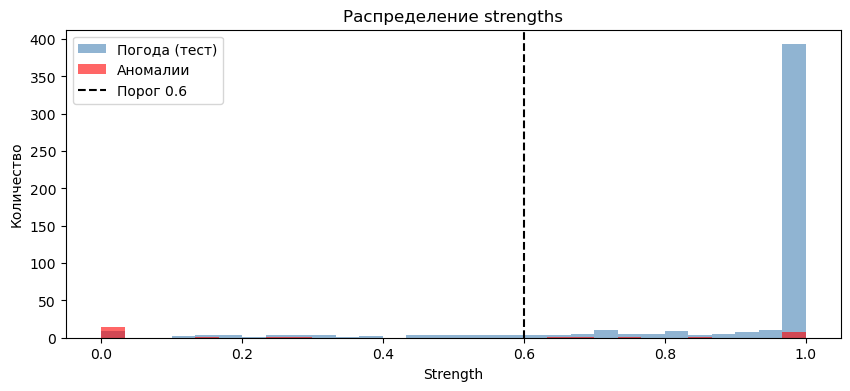

Погода — средний strength: 0.905
Аномалии — средний strength: 0.387


In [ ]:
predicted_labels, strengths = hdbscan.approximate_predict(clusterer, test_embedding_2d)
labels_arr = np.array(test_labels)

plt.figure(figsize=(10, 4))
plt.hist(strengths[labels_arr == 0], bins=30, alpha=0.6, color="steelblue", label="Погода (тест)")
plt.hist(strengths[labels_arr == 1], bins=30, alpha=0.6, color="red", label="Аномалии")
plt.axvline(x=0.6, color="black", linestyle="--", label="Порог 0.6")
plt.xlabel("Strength")
plt.ylabel("Количество")
plt.legend()
plt.title("Распределение strengths")
plt.show()

print(f"Погода — средний strength: {strengths[labels_arr == 0].mean():.3f}")
print(f"Аномалии — средний strength: {strengths[labels_arr == 1].mean():.3f}")

In [81]:
print(f"{'Порог':>8} {'TP':>4} {'FP':>4} {'FN':>4} {'Recall':>8} {'Precision':>10} {'F1':>6}")

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = (strengths < threshold).astype(int)
    tp_ = ((pred == 1) & (labels_arr == 1)).sum()
    fp_ = ((pred == 1) & (labels_arr == 0)).sum()
    fn_ = ((pred == 0) & (labels_arr == 1)).sum()
    recall = tp_ / 30
    precision = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{threshold:>8.1f} {tp_:>4} {fp_:>4} {fn_:>4} {recall:>8.2%} {precision:>10.2%} {f1:>6.3f}")

   Порог   TP   FP   FN   Recall  Precision     F1
     0.1   15    9   15   50.00%     62.50%  0.556
     0.2   16   18   14   53.33%     47.06%  0.500
     0.3   18   25   12   60.00%     41.86%  0.493
     0.4   18   31   12   60.00%     36.73%  0.456
     0.5   18   39   12   60.00%     31.58%  0.414
     0.6   18   50   12   60.00%     26.47%  0.367
     0.7   20   62   10   66.67%     24.39%  0.357
     0.8   21   82    9   70.00%     20.39%  0.316


In [ ]:
# strength близкий к 0 = не вписывается в кластер погоды = аномалия
predictions = (strengths < 0.1).astype(int)
# Подсчёт кластеров (на обучающих данных)
train_labels = clusterer.labels_
n_clusters = len(set(train_labels)) - (1 if -1 in train_labels else 0)


# Подсчёт аномалий (на тестовых данных)
labels_arr = np.array(test_labels)
tp = ((predictions == 1) & (labels_arr == 1)).sum()
fp = ((predictions == 1) & (labels_arr == 0)).sum()
fn = ((predictions == 0) & (labels_arr == 1)).sum()
tn = ((predictions == 0) & (labels_arr == 0)).sum()
print(f"Кластеров найдено: {n_clusters}")

print(f"Аномалий поймано (TP): {tp}/30")
print(f"Ложных тревог (FP): {fp}")
print(f"Пропущено (FN): {fn}")
print(f"(TN): {tn}")
print(f"Recall: {tp/30:.2%}")

Кластеров найдено: 10
Аномалий поймано (TP): 15/30
Ложных тревог (FP): 9
Пропущено (FN): 15
(TN): 503
Recall: 50.00%


In [ ]:
print("\n=== необнаруженные аномалий (FN) ===")
anomalii = 0
for i, (true, pred, text) in enumerate(zip(test_labels, predictions, texts)):
    if true == 1 and pred == 0:
        print(f"  - {text}")
        anomalii+=1
print("anomalii упущено:",anomalii)
print("\n=== ложных срабатывания (FP) ===")
fp_count = 0
for i, (true, pred, text) in enumerate(zip(test_labels, predictions, texts)):
    if true == 0 and pred == 1:
        print(f"  - {text}")
        fp_count += 1
total_anomalies = sum(1 for l in test_labels if l == 1)  # всего аномалий = 30
fn = anomalii                                         # пропущено = 27
tp = total_anomalies - fn


print(f"Всего аномалий: {total_anomalies}")
print(f"Поймано (TP): {tp}")
print(f"Пропущено (FN): {fn}")
print(f"Recall: {tp / total_anomalies:.2%}")  


=== необнаруженные аномалий (FN) ===
  - Учения в кенийском аэропорту приняли за авиакатастрофу
  - Депутат Думы предложил запретить Хеллоуин из-за авиакатастрофы
  - Найдена самая близкая к Земле двойная черная дыра
  - Саакашвили открыл детский лагерь в зоне вооруженного конфликта
  - В Швейцарии по вине черепахи произошла автокатастрофа
  - Чрезвычайное положение в Южной Осетии: отправлены в отставку главы ключевых ведомств
  - Владелец клуба высказался о конфликте девушки-трансгендера с охраной
  - На востоке Индии потерпел катастрофу МиГ-23
  - Экспертизу тел погибших в катастрофе Ан-148 отложили после пожара в Кемерове
  - «Коммерсантъ» сообщил об отсутствии информации о катастрофе на самописце А321  
  - Пресс-служба Чиркунова разъяснила суть конфликта с прессой
  - Из-за бунта в Кербенте на юге Киргизии могут ввести чрезвычайное положение
  - В зоне грузино-осетинского конфликта обстреляли наблюдателей ОБСЕ
  - Мать с младенцем прожили пять дней в колумбийских джунглях после а

# Финальная конфигурация baseline
# Модель:     paraphrase-multilingual-mpnet-base-v2
# UMAP:       n_neighbors=15, min_dist=0.1, metric=cosine
# HDBSCAN:    min_cluster_size=125, min_samples=5
# Порог:      strength < 0.1 → аномалия

predictions = (strengths < 0.1).astype(int)

In [91]:
for c in range(10):
    mask = clusterer.labels_ == c
    cluster_texts = [train_weather_texts[i] for i in range(len(train_weather_texts)) if mask[i]]
    # берём первые 3 текста из кластера
    print(f"\nКластер {c}:")
    for t in cluster_texts[:3]:
        print(f"  {t}")


Кластер 0:
  В городе Пермь: ясно, температура 1°C, ветер 7 км/ч.
  В городе Пермь: преимущественно ясно, температура 0°C, ветер 5 км/ч.
  В городе Пермь: пасмурно, температура 4°C, ветер 8 км/ч.

Кластер 1:
  В городе Санкт-Петербург: ясно, температура 4°C, ветер 16 км/ч.
  В городе Санкт-Петербург: ясно, температура 4°C, ветер 18 км/ч.
  В городе Санкт-Петербург: ясно, температура 5°C, ветер 19 км/ч.

Кластер 2:
  В городе Москва: небольшой снег, температура 2°C, ветер 19 км/ч.
  В городе Москва: небольшой снег, температура 2°C, ветер 22 км/ч.
  В городе Москва: небольшой снег, температура 1°C, ветер 22 км/ч.

Кластер 3:
  В городе Казань: переменная облачность, температура 1°C, ветер 4 км/ч.
  В городе Казань: переменная облачность, температура 0°C, ветер 3 км/ч.
  В городе Казань: ясно, температура 5°C, ветер 2 км/ч.

Кластер 4:
  В городе Новосибирск: пасмурно, температура -2°C, ветер 8 км/ч.
  В городе Новосибирск: переменная облачность, температура -2°C, ветер 11 км/ч.
  В горо

сверху видим кластеризацию по городам

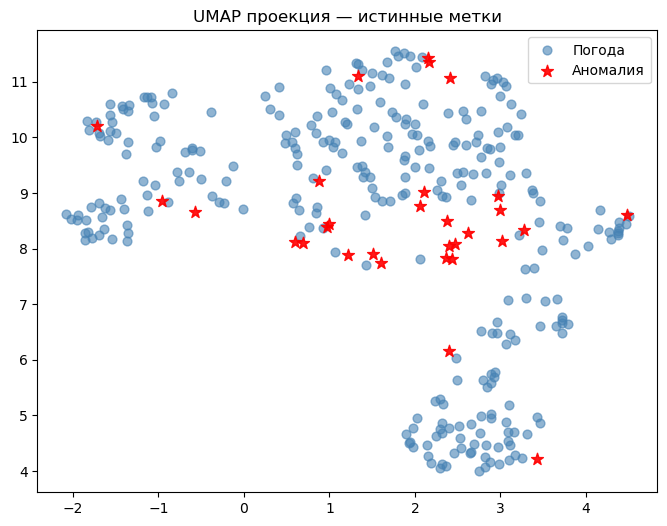

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels_arr = np.array(test_labels)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[labels_arr == 0, 0], 
            embedding_2d[labels_arr == 0, 1],
            c="steelblue", alpha=0.6, s=40, label="Погода")
plt.scatter(embedding_2d[labels_arr == 1, 0], 
            embedding_2d[labels_arr == 1, 1],
            c="red", alpha=0.9, s=80, marker="*", label="Аномалия")
plt.legend()
plt.title("UMAP проекция — истинные метки")
plt.show()

Метрики

In [92]:
from sklearn.metrics import silhouette_score
import numpy as np

# Силуэт считается только по точкам внутри кластеров (без шума -1)
mask_in_cluster = clusterer.labels_ != -1

if mask_in_cluster.sum() > 1:
    sil = silhouette_score(
        train_embedding_2d[mask_in_cluster], 
        clusterer.labels_[mask_in_cluster]
    )
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Точек в кластерах: {mask_in_cluster.sum()}/{len(train_embedding_2d)}")
    print(f"Шумовых точек: {(~mask_in_cluster).sum()}")
else:
    print("Недостаточно точек в кластерах")

Silhouette Score: 0.7664
Точек в кластерах: 1689/2048
Шумовых точек: 359


OPTUNA

In [8]:
import pandas as pd
import optuna

ModuleNotFoundError: No module named 'optuna'

In [ ]:
parameters_grid = {
    "min_cluster_size":              (20, 300),
    "min_samples":                   (1, 20),
    "cluster_selection_epsilon":     (0.0, 1.0),
    "cluster_selection_persistence": (0.0, 1.0),
    "metric":                        ["euclidean", "manhattan", "minkowski"],
    "alpha":                         (0.5, 1.5),
    "cluster_selection_method":      ["eom", "leaf"],
    "allow_single_cluster":          [True, False],
}

In [ ]:
#train_embeddings
def objective(X_train,X_val,y_val ,trial, n_fold=3):
    
    parameters = {
        "min_cluster_size":              trial.suggest_int("min_cluster_size", *parameters_grid["min_cluster_size"]),
        "min_samples":                   trial.suggest_int("min_samples", *parameters_grid["min_samples"]),
        "cluster_selection_epsilon":     trial.suggest_float("cluster_selection_epsilon", *parameters_grid["cluster_selection_epsilon"]),
        "cluster_selection_persistence": trial.suggest_float("cluster_selection_persistence", *parameters_grid["cluster_selection_persistence"]),
        "metric":                        trial.suggest_categorical("metric", parameters_grid["metric"]),
        "alpha":                         trial.suggest_float("alpha", *parameters_grid["alpha"]),
        "cluster_selection_method":      trial.suggest_categorical("cluster_selection_method", parameters_grid["cluster_selection_method"]),
        "allow_single_cluster":          trial.suggest_categorical("allow_single_cluster", parameters_grid["allow_single_cluster"]),
    }

    fold_1 = X_train[:(len(X_train)//n_fold)]
    fold_2 = X_train[len(X_train)//n_fold:(len(X_train) - (len(X_train)//n_fold))]
    fold_3 = X_train[(len(X_train) - (len(X_train)//n_fold)):]
    
    val_1 = X_val[:(len(X_val)//n_fold)]
    val_2 = X_val[len(X_val)//n_fold:(len(X_val) - (len(X_val)//n_fold))]
    val_3 = X_val[(len(X_val) - (len(X_val)//n_fold)):]

    y_val_1 = y_val[:(len(y_val)//n_fold)]
    y_val_2 = y_val[len(y_val)//n_fold:(len(y_val) - (len(y_val)//n_fold))]
    y_val_3 = y_val[(len(y_val) - (len(y_val)//n_fold)):]

    folds = [fold_1, fold_2, fold_3]
    vals = [val_1,val_2,val_3]
    y_vals = [y_val_1, y_val_2, y_val_3]

    sil_scores = []
    f1_scores = []


    fold_num=0
    for fold in folds:
        
        x_train = fold
        y_val = y_vals[fold_num]
        val_folds = [other_fold for other_fold in folds if other_fold != fold]
        x_val = np.concatenate([val_folds,vals[fold_num]], axis=0)
        np.random.shuffle(x_val)
        

        clusterer = hdbscan.HDBSCAN(**parameters, prediction_data = True).fit(x_train)
        _, strengths = hdbscan.approximate_predict(clusterer, x_val)

        mask_in_cluster = clusterer.labels_ != -1
        if mask_in_cluster.sum() < 2:
            return 0.0
        sil = silhouette_score(
            x_train[mask_in_cluster],
            clusterer.labels_[mask_in_cluster]
        )
        sil_scores.append(sil)

        best_f1 = 0.0
        for threshold in np.arange(0.05, 0.5, 0.05):
            predictions = (strengths < threshold).astype(int)
            f1 = f1_score(y_val, predictions, zero_division=0)
            best_f1 = max(best_f1, f1)
        f1_scores.append(best_f1)
        fold_num+=1

    return np.mean(sil_scores), np.mean(f1_scores)